1) Метод серединных квадратов
2. Метод серединных произведений
3) Метод перемешивания

На основе этих трёх алгоритмов создать свой алгоритм ГСЧ. 
Получить 1024 случайных числа, в отрезке $[-1; 1]$, имеющие 6 знаков после запятой

$R_0 = clock$ - часы минуты секунды

4) Построить график значение от времени

5) Посчитать $M$ - мат ожидание 
$$M = \frac{\sum_i^n a_i}{n} $$
$D$ - Дисперсия
$$D = \frac1{n}\sum_i^n(a_i - M)^2 $$
$\sigma$ - среднеквадратичное отклонение
$$\sigma = \sqrt{D}$$

In [65]:
import matplotlib.pyplot as plt
import time
import numpy as np

In [66]:
def GetMiddleOfNumber(number):
    str_num = str(number)
    
    middle = str_num[len(str_num) // 4:-len(str_num) // 4]
    
    return int(middle)

In [67]:
def MethodMiddleSquare(number, N=1):    
    num = number
    
    for _ in range(N):
        num = GetMiddleOfNumber(num)
        num *= num
    
        # print(num)
    return num

In [68]:
MethodMiddleSquare(12345678)

11943936

In [69]:
a = [1, 2, 3, 4, 5, 6]
a[2:], a[:2]

([3, 4, 5, 6], [1, 2])

In [70]:
def MethodMiddleMultiply(number, N=1): 
    R0 = 39572034
    R1 = number
    for _ in range(N):
        num = GetMiddleOfNumber(R1) * GetMiddleOfNumber(R0)
        R0 = R1
        R1 = num
    return R1

In [71]:
def MethodMiddleMixing(number, N=1):
    
    for _ in range(N):
        l = len(str(number)) // 4
        strnum = str(number)
        R0 = strnum[l:] + strnum[:l]
        R1 = strnum[-l:] + strnum[:-l]
        
        num0 = int(R0)
        num1 = int(R1)
        
        number = num0 + num1
        print(num0, num1, number)
    return number
    

In [72]:
MethodMiddleMixing(12345678)

34567812 78123456 112691268


112691268

In [73]:
def my_random(r_0=None, M=100_000_000):
    if r_0 == None:
        import time
        current_time = time.time()
        r_0 = int(current_time * 100000)
    

    R0 = MethodMiddleMixing(r_0)
    R1 = MethodMiddleSquare(r_0)
    
    R0 = (R0 + MethodMiddleMultiply(R1)) % M
    
    R1 = (R1 + MethodMiddleMixing(R0)) % M
    
    R0 = MethodMiddleSquare(R0) % M
    R1 = MethodMiddleMixing(R1) % M
    
    result = int(R0 + R1) % 1_000_000
    return result


In [74]:
N = 1024

rand_arr = []

for _ in range(N):
    current_time = time.time()
    milliseconds = int(current_time * 100000)
    
    rand_arr.append(my_random(milliseconds))


502828545107177 107177502828545 610006047935722
38508260 82603850 121112110
49742627 26274974 76017601
502828545142177 142177502828545 645006047970722
42008260 82604200 124612460
99777630 76309977 176087607
502828545148177 148177502828545 651006047976722
42608260 82604260 125212520
59783631 36315978 96099609
502828545153177 153177502828545 656006047981722
43108260 82604310 125712570
9788632 86320978 96109610
502828545157177 157177502828545 660006047985722
43508260 82604350 126112610
49792632 26324979 76117611
502828545161177 161177502828545 664006047989722
43908260 82604390 126512650
89796632 66328979 156125611
502828545166177 166177502828545 669006047994722
44408260 82604440 127012700
39801633 16333980 56135613
502828545171177 171177502828545 674006047999722
44908260 82604490 127512750
89806633 66338980 156145613
502828545176177 176177502828545 679006048004722
45408260 82604540 128012800
39811634 16343981 56155615
502828545181177 181177502828545 684006048009722
45908260 82604590 12851

In [75]:
def normalization(arr):
    max_num = max(arr)
    
    arr = [arr[i] - max_num / 2 for i in range(len(arr))]
    print(arr)

    arr = [arr[i] / max_num * 2 for i in range(len(arr))]
    
    print(arr)
    return arr

In [76]:
iters = [i for i in range(1024)]

print(rand_arr)
rand_arr = normalization(rand_arr)

[840101, 727607, 247209, 685710, 40111, 397711, 849213, 305713, 767215, 233715, 610517, 990517, 373718, 857219, 247619, 641221, 137721, 639223, 145723, 657225, 173725, 695227, 221727, 646529, 182029, 722531, 377731, 929233, 597633, 160135, 613735, 185237, 646037, 226539, 929739, 521241, 117741, 598543, 204043, 814545, 430045, 50547, 550547, 53748, 687249, 197649, 711251, 228051, 748052, 534053, 62054, 593255, 261756, 935257, 477658, 160159, 709759, 401261, 97761, 799263, 364063, 74565, 790065, 366066, 90567, 820068, 407269, 145770, 889271, 487672, 240173, 997674, 607275, 220075, 990577, 610577, 390078, 17279, 805780, 440181, 77781, 718583, 524083, 334585, 986585, 641786, 465287, 127688, 793289, 629789, 302591, 978591, 657792, 340193, 25793, 887295, 753795, 450597, 150597, 30098, 737299, 447700, 161301, 878101, 598102, 321303, 47704, 777305, 510105, 246106, 985307, 727708, 487712, 440213, 397714, 167315, 940115, 910617, 690617, 670118, 457319, 445820, 240221, 237722, 240223, 45823, 2574

In [77]:
M = sum(rand_arr) / N
M

0.004430376783286089

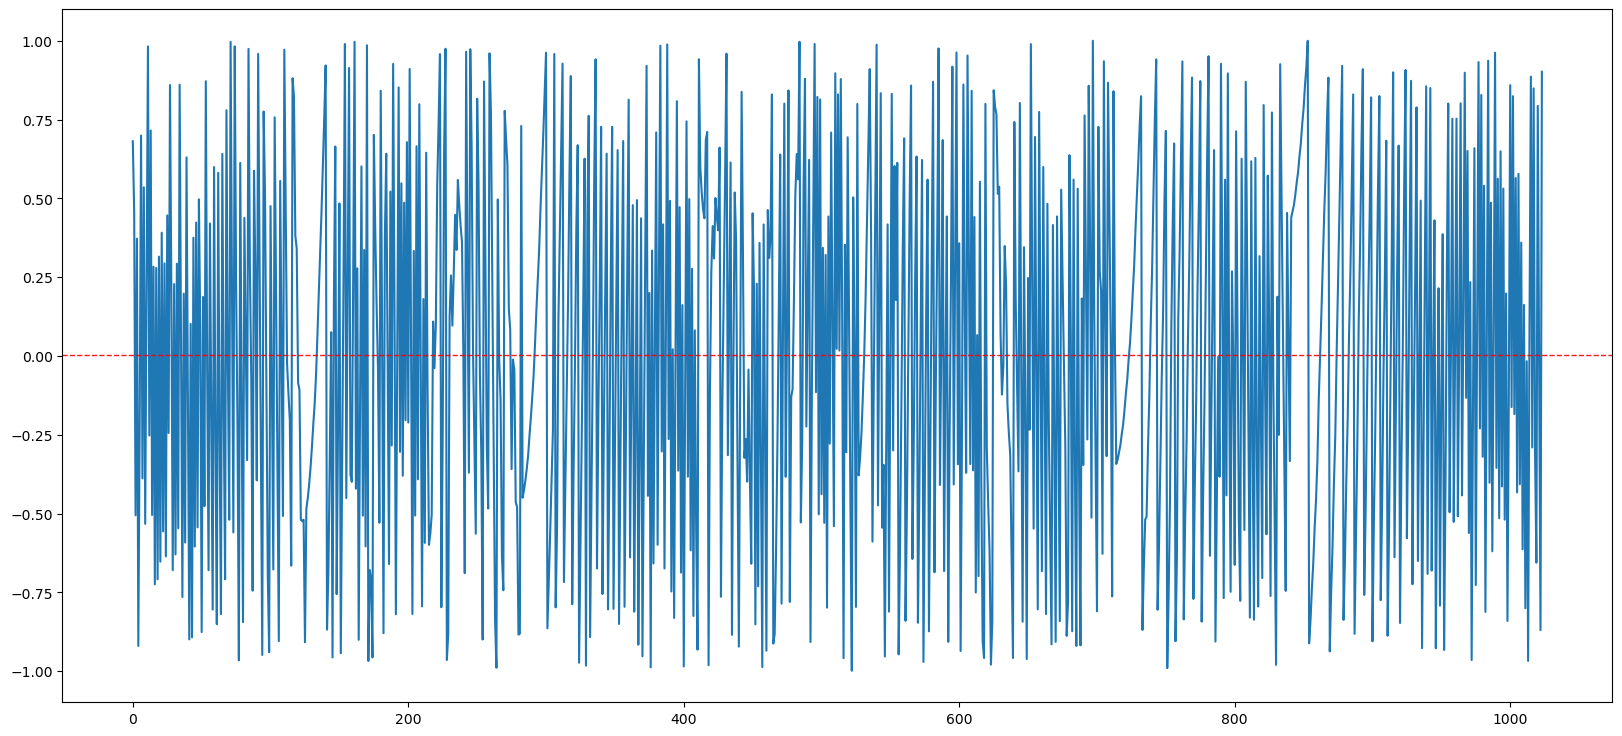

In [78]:
fig, ax = plt.subplots(figsize=(20, 9)) 

plt.plot(iters, rand_arr)

ax.axhline(y=M, color='red', linestyle='--', linewidth=1, alpha=0.9)

In [79]:
q_sum = 0
for el in rand_arr:
    q_sum += (el - M)**2
    
D = q_sum / N
sigma = np.sqrt(D)
D, sigma

(0.330611491366883, np.float64(0.5749882532425189))

In [80]:
print('Характеристики генератора')
print(f'Математическое ожидание M = {M}')
print(f'Дисперсия D = {D}')
print(f'Среднеквадратическое отклонение = {sigma}')

Характеристики генератора
Математическое ожидание M = 0.004430376783286089
Дисперсия D = 0.330611491366883
Среднеквадратическое отклонение = 0.5749882532425189


In [81]:
rand_arr[355]

0.16485678179022012

ручусь печать на ней вот я